# MobileNet - Оценка на модела (Evaluation)
Този ноутбук зарежда обучения модел и го оценява върху тестовия набор от данни.

In [1]:
import os
import sys
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.models.mobilenet_model import AudioMobileNetV2
from src.data_processing.audio_dataset import AudioFolderDataset

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Използвано устройство: {DEVICE}")

TEST_CSV = "../data/test_split.csv"
AUDIO_DIR = "../data/Dataset_Final"
MODEL_WEIGHTS = "../models/3_mobilenet.pth"
BATCH_SIZE = 32

Използвано устройство: cpu


In [3]:
print("Зареждане на тестовите данни...")
# Използвай новия параметър csv_file
test_dataset = AudioFolderDataset(root_dir="../data/Dataset_Final", csv_file=TEST_CSV, augment=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f"Брой тестови записи: {len(test_dataset)}")


Зареждане на тестовите данни...
Зареждане на данни от сплит файл: ../data/test_split.csv
Брой тестови записи: 443


In [4]:
print("Инициализация на модела...")
model = AudioMobileNetV2(n_classes=8).to(DEVICE)

print("Зареждане на запазените тегла...")
if os.path.exists(MODEL_WEIGHTS):
    model.load_state_dict(torch.load(MODEL_WEIGHTS, map_location=DEVICE))
    model.eval()
    print("Моделът е зареден успешно!")
else:
    print(f"ГРЕШКА: Файлът с теглата не е намерен на път {MODEL_WEIGHTS}")

Инициализация на модела...
Зареждане на запазените тегла...
Моделът е зареден успешно!


In [5]:
all_preds = []
all_labels = []

print("Стартиране на инференцията...")
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Testing"):
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Оценката приключи!")

Стартиране на инференцията...


Testing:   0%|          | 0/14 [00:00<?, ?it/s]

Оценката приключи!


In [6]:
class_names = [
    "Baby_Cry", "Background", "Car_Horn", "Construction", 
    "Dog_Bark", "Door_Signal", "Glass_Break", "Siren_Alarm"
]


print("--- Доклад от класификацията (Classification Report) ---")
print(classification_report(all_labels, all_preds, target_names=class_names))

--- Доклад от класификацията (Classification Report) ---
              precision    recall  f1-score   support

    Baby_Cry       1.00      0.80      0.89        40
  Background       0.90      0.99      0.94        70
    Car_Horn       0.98      1.00      0.99        43
Construction       0.77      1.00      0.87        70
    Dog_Bark       0.80      1.00      0.89        70
 Door_Signal       1.00      0.95      0.97        40
 Glass_Break       1.00      0.10      0.18        40
 Siren_Alarm       1.00      1.00      1.00        70

    accuracy                           0.89       443
   macro avg       0.93      0.85      0.84       443
weighted avg       0.91      0.89      0.87       443



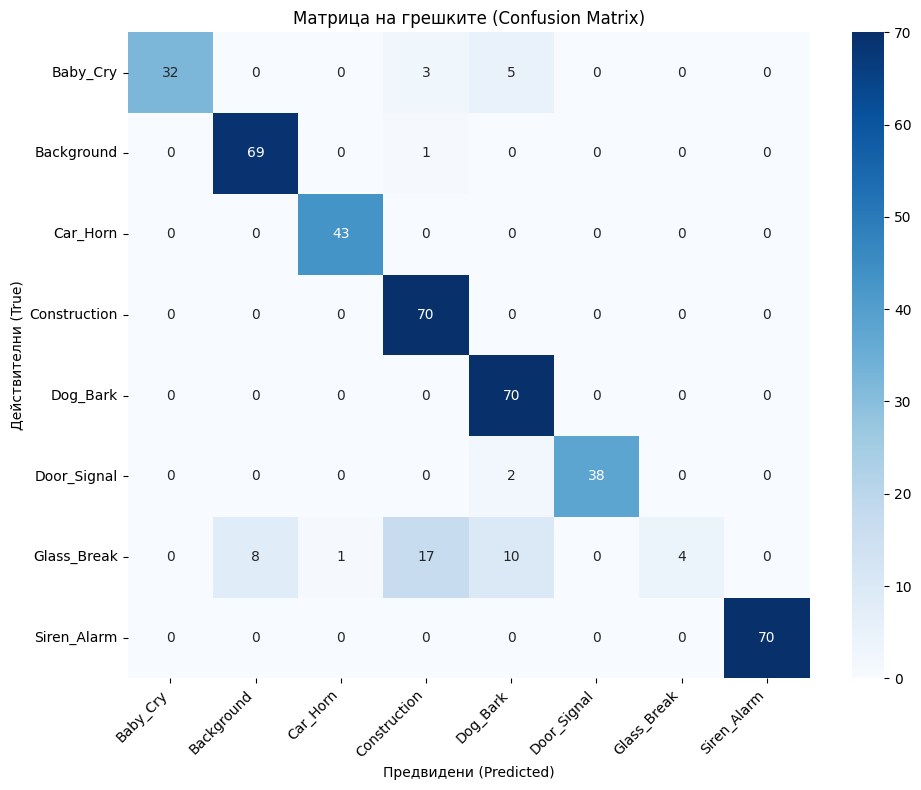

In [7]:
plt.figure(figsize=(10, 8))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Предвидени (Predicted)')
plt.ylabel('Действителни (True)')
plt.title('Матрица на грешките (Confusion Matrix)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Анализ на резултатите: MobileNetV2 Sound Classification
1. Общ преглед на производителността
Моделът постига впечатляваща обща точност (Accuracy) от 89% върху тестовия набор от данни. В сравнение с предишната итерация, където доминираше класът gun_shot, текущата архитектура показва висока способност за дискриминация между различните акустични събития.

Ключови метрики:

Precision (Macro Avg): 0.93

Recall (Macro Avg): 0.85

F1-Score (Weighted Avg): 0.87

2. Детайлен анализ по класове
✅ Отличници (Перфектно разпознаване)

🚨 Siren_Alarm: Постига абсолютен максимум с 1.00 Precision и 1.00 Recall. Всички 70 тестови записа са разпознати без нито една грешка.

🚗 Car_Horn: Моделът е изключително прецизен тук (1.00 Recall), като само в 2% от случаите бърка друг звук за клаксон.

🛠️ Construction & 🐕 Dog_Bark: И двата класа показват 1.00 Recall. Това гарантира, че приложението винаги ще извести потребителя при наличие на строителен шум или лай, макар и с малък риск от фалшиви сигнали (Precision ~0.80).

👶 Социално значими класове

Baby_Cry: Постига висока прецизност (1.00), което означава нула фалшиви аларми за бебешки плач. Постигнатият Recall от 0.80 показва, че 8 от 40 записа са пропуснати (класифицирани като Dog_Bark или Construction), но резултатът остава солиден за мобилно приложение.

Door_Signal: Много стабилно представяне с 0.97 F1-score. Почти всяко чукане или звънец ще бъдат уловени правилно.

🤫 Ефективност на филтъра за фон (Background)

Класът Background демонстрира 0.99 Recall. Това потвърждава, че стратегията за "кошче за шумове" работи – 69 от 70 записа на околен шум са филтрирани успешно, предотвратявайки ненужни известия към потребителя.

3. Идентифицирани предизвикателства
⚠️ Критична зона: Glass_Break

Това е най-слабият сегмент на модела с Recall от едва 0.10.

Проблем: Само 4 от 40 записа на чупещо се стъкло са разпознати правилно.

Корелация: Голяма част от тези звуци (17 броя) се припокриват с класа Construction. Това се дължи на подобния импулсен характер и високи честоти на двата звука.